# DE Results Analysis: Cross-Variant Comparison

This notebook processes the Differential Expression (DE) results from all 8 variants of the analysis.
We aim to:
1. Identify how many genes are significantly differentially expressed (`padj < 0.05`) in each variant.
2. Compare the ratio of significant genes to the background of valid genes.
3. Analyze the intersection/overlap of these significant genes across the different analyses.

In [15]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from settings import PROJECT_ROOT, DATA_ROOT, DATASET_ROOT

# Optional: set seaborn style for nicer plots
sns.set_theme(style="whitegrid")

In [16]:
# Define the root directory for DE results
de_dir = os.path.join(DATASET_ROOT, '04_DE_Analysis_results')

# Find all DE result CSV files using a glob pattern
search_pattern = os.path.join(de_dir, '*', '*_DE_results_*.csv')
de_files = glob.glob(search_pattern)

print(f"Found {len(de_files)} DE result files.")

results_summary = []
all_significant_genes = []

for file_path in sorted(de_files):
    # Extract a clean name for the analysis variant from the parent folder name
    folder_name = os.path.basename(os.path.dirname(file_path))
    analysis_name = folder_name.split('-', 1)[-1] if '-' in folder_name else folder_name
    
    # Load the CSV
    df = pd.read_csv(file_path)
    
    # Filter out rows where 'padj' is NA (these are genes with extremely low counts ignored by DESeq2)
    valid_genes_df = df.dropna(subset=['padj'])
    total_valid = len(valid_genes_df)
    
    # Filter for statistically significant genes
    sig_df = valid_genes_df[valid_genes_df['padj'] < 0.05]
    sig_count = len(sig_df)
    
    # Calculate percentage
    ratio = (sig_count / total_valid * 100) if total_valid > 0 else 0
    
    results_summary.append({
        'Analysis Variant': analysis_name,
        'Total Valid Genes': total_valid,
        'Significant Genes': sig_count,
        '% Significant': round(ratio, 2)
    })
    
    # Extract unique gene names for overlap tracking
    # (We use 'gene_name' as this is what matches the circRNA matrix HGNC symbols)
    sig_gene_names = sig_df['gene_name'].dropna().unique()
    all_significant_genes.extend(sig_gene_names)
    
# Display the summary table
summary_df = pd.DataFrame(results_summary)
display(summary_df)

Found 8 DE result files.


,Analysis Variant,Total Valid Genes,Significant Genes,% Significant
0,Pre_vs_Post_treatment,25182,1,0.00
1,Pre_vs_During_treatment,23251,35,0.15
2,SHAPS,24023,0,0.00
3,TEPS,24023,1,0.00
4,GAD7,24023,0,0.00
5,IDSC,24023,0,0.00
6,YMRS,20177,24,0.12
7,Response_to_treatment,26191,180,0.69


In [17]:
# Count how many analyses each unique gene appeared in
gene_counts = Counter(all_significant_genes)

# Convert the Counter dictionary to a Pandas DataFrame
overlap_df = pd.DataFrame.from_dict(gene_counts, orient='index', columns=['Appearance_Count'])
overlap_df.index.name = 'Gene'
overlap_df = overlap_df.reset_index()

# Tally the frequencies (how many genes appeared 1 time, 2 times, etc.)
frequency_distribution = overlap_df['Appearance_Count'].value_counts().sort_index()

print("Gene Overlap Frequency Distribution:")
print(frequency_distribution)

Gene Overlap Frequency Distribution:
Appearance_Count
1    241
Name: count, dtype: int64


In [18]:
import pandas as pd
import os
import glob

de_dir = os.path.join(DATASET_ROOT, '04_DE_Analysis_results')
search_pattern = os.path.join(de_dir, '*', '*_DE_results_*.csv')
de_files = glob.glob(search_pattern)

all_sig_genes_data = []

# Loop through the files, using 'enumerate' to get our numeric code (0 to 7)
for i, file_path in enumerate(sorted(de_files)):
    folder_name = os.path.basename(os.path.dirname(file_path))
    analysis_name = folder_name.split('-', 1)[-1] if '-' in folder_name else folder_name
    
    # Numeric code for this analysis
    analysis_code = i
    
    df = pd.read_csv(file_path)
    
    # Filter strictly for significant genes
    sig_df = df[df['padj'] < 0.05].copy()
    
    if not sig_df.empty:
        # Inject our custom tracking columns
        sig_df['analysis_name'] = analysis_name
        sig_df['analysis_code'] = analysis_code
        
        # Select and reorder exactly the columns we discussed
        cols_to_keep = [
            'gene_name', 'gene_id', 'gene_type', 
            'analysis_name', 'analysis_code', 
            'padj', 'log2FoldChange', 'baseMean'
        ]
        
        all_sig_genes_data.append(sig_df[cols_to_keep])

# Combine all the data into one massive master table
master_sig_df = pd.concat(all_sig_genes_data, ignore_index=True)

# # Save the final CSV to the data directory
# output_csv = '/Users/ppopov1/_circRNA/docs/01_on_data/data/significant_DE_genes.csv'
# master_sig_df.to_csv(output_csv, index=False)

# print(f"Master CSV successfully saved with {len(master_sig_df)} significant gene entries!")
# display(master_sig_df.head(10))


In [19]:
import pandas as pd
import numpy as np

master_csv = os.path.join(DATA_ROOT, 'significant_DE_genes.csv')
# master_df = pd.read_csv(master_csv)
master_df = master_sig_df

# Load the counts files so we can pull the exact IDs
circ_df = pd.read_csv(os.path.join(DATA_ROOT, 'circRNA_counts.csv'))
lin_df = pd.read_csv(os.path.join(DATA_ROOT, 'linRNA_counts.csv'))

# 1. Create a dictionary to map HGNC Gene symbol -> circRNA_id
circ_map = dict(zip(circ_df['Gene'], circ_df['circRNA_id']))

# 2. Create a set of valid linRNA IDs (to verify they actually survived filtering)
lin_valid_ids = set(lin_df['gene_id'].dropna())

# Map circRNA_id based on gene_name. If missing, it automatically assigns np.nan
master_df['circRNA_ID'] = master_df['gene_name'].map(circ_map)

# Map linRNA_ID. It's the same as gene_id, BUT we only assign it if it exists in our filtered matrix!
master_df['linRNA_ID'] = master_df['gene_id'].apply(lambda x: x if x in lin_valid_ids else np.nan)

# Let's cleanly organize the columns to put these new IDs right at the front
cols = ['circRNA_ID', 'linRNA_ID'] + [c for c in master_df.columns if c not in ['circRNA_ID', 'linRNA_ID']]
master_df = master_df[cols]

# Save it back to the exact same file
master_df.to_csv(master_csv, index=False)

print(f"Updated CSV! Successfully mapped {master_df['circRNA_ID'].notna().sum()} circRNA IDs and {master_df['linRNA_ID'].notna().sum()} linRNA IDs.")
display(master_df.head(10))


Updated CSV! Successfully mapped 8 circRNA IDs and 229 linRNA IDs.


,circRNA_ID,linRNA_ID,gene_name,gene_id,gene_type,analysis_name,analysis_code,padj,log2FoldChange,baseMean
0,NaN,ENSG00000242534.2,IGKV2D-28,ENSG00000242534.2,IG_V_gene,Pre_vs_Post_treatment,0,0.000075,5.864964,8.417815
1,NaN,ENSG00000082146.13,STRADB,ENSG00000082146.13,protein_coding,Pre_vs_During_treatment,1,0.000429,0.709915,6958.264451
2,NaN,ENSG00000124098.10,FAM210B,ENSG00000124098.10,protein_coding,Pre_vs_During_treatment,1,0.000492,0.728523,3800.471156
3,NaN,ENSG00000119950.21,MXI1,ENSG00000119950.21,protein_coding,Pre_vs_During_treatment,1,0.013465,0.557115,2948.350453
4,NaN,ENSG00000004939.15,SLC4A1,ENSG00000004939.15,protein_coding,Pre_vs_During_treatment,1,0.013465,0.686496,17208.167903
5,NaN,ENSG00000066926.11,FECH,ENSG00000066926.11,protein_coding,Pre_vs_During_treatment,1,0.013465,0.565519,2540.758364
6,NaN,ENSG00000159346.13,ADIPOR1,ENSG00000159346.13,protein_coding,Pre_vs_During_treatment,1,0.013465,0.619142,18153.136226
7,NaN,ENSG00000198876.13,DCAF12,ENSG00000198876.13,protein_coding,Pre_vs_During_treatment,1,0.013465,0.631369,19728.139062
8,NaN,ENSG00000183508.5,TENT5C,ENSG00000183508.5,protein_coding,Pre_vs_During_treatment,1,0.013465,0.671267,17696.782244
9,NaN,ENSG00000047597.7,XK,ENSG00000047597.7,protein_coding,Pre_vs_During_treatment,1,0.013465,0.821353,463.963967


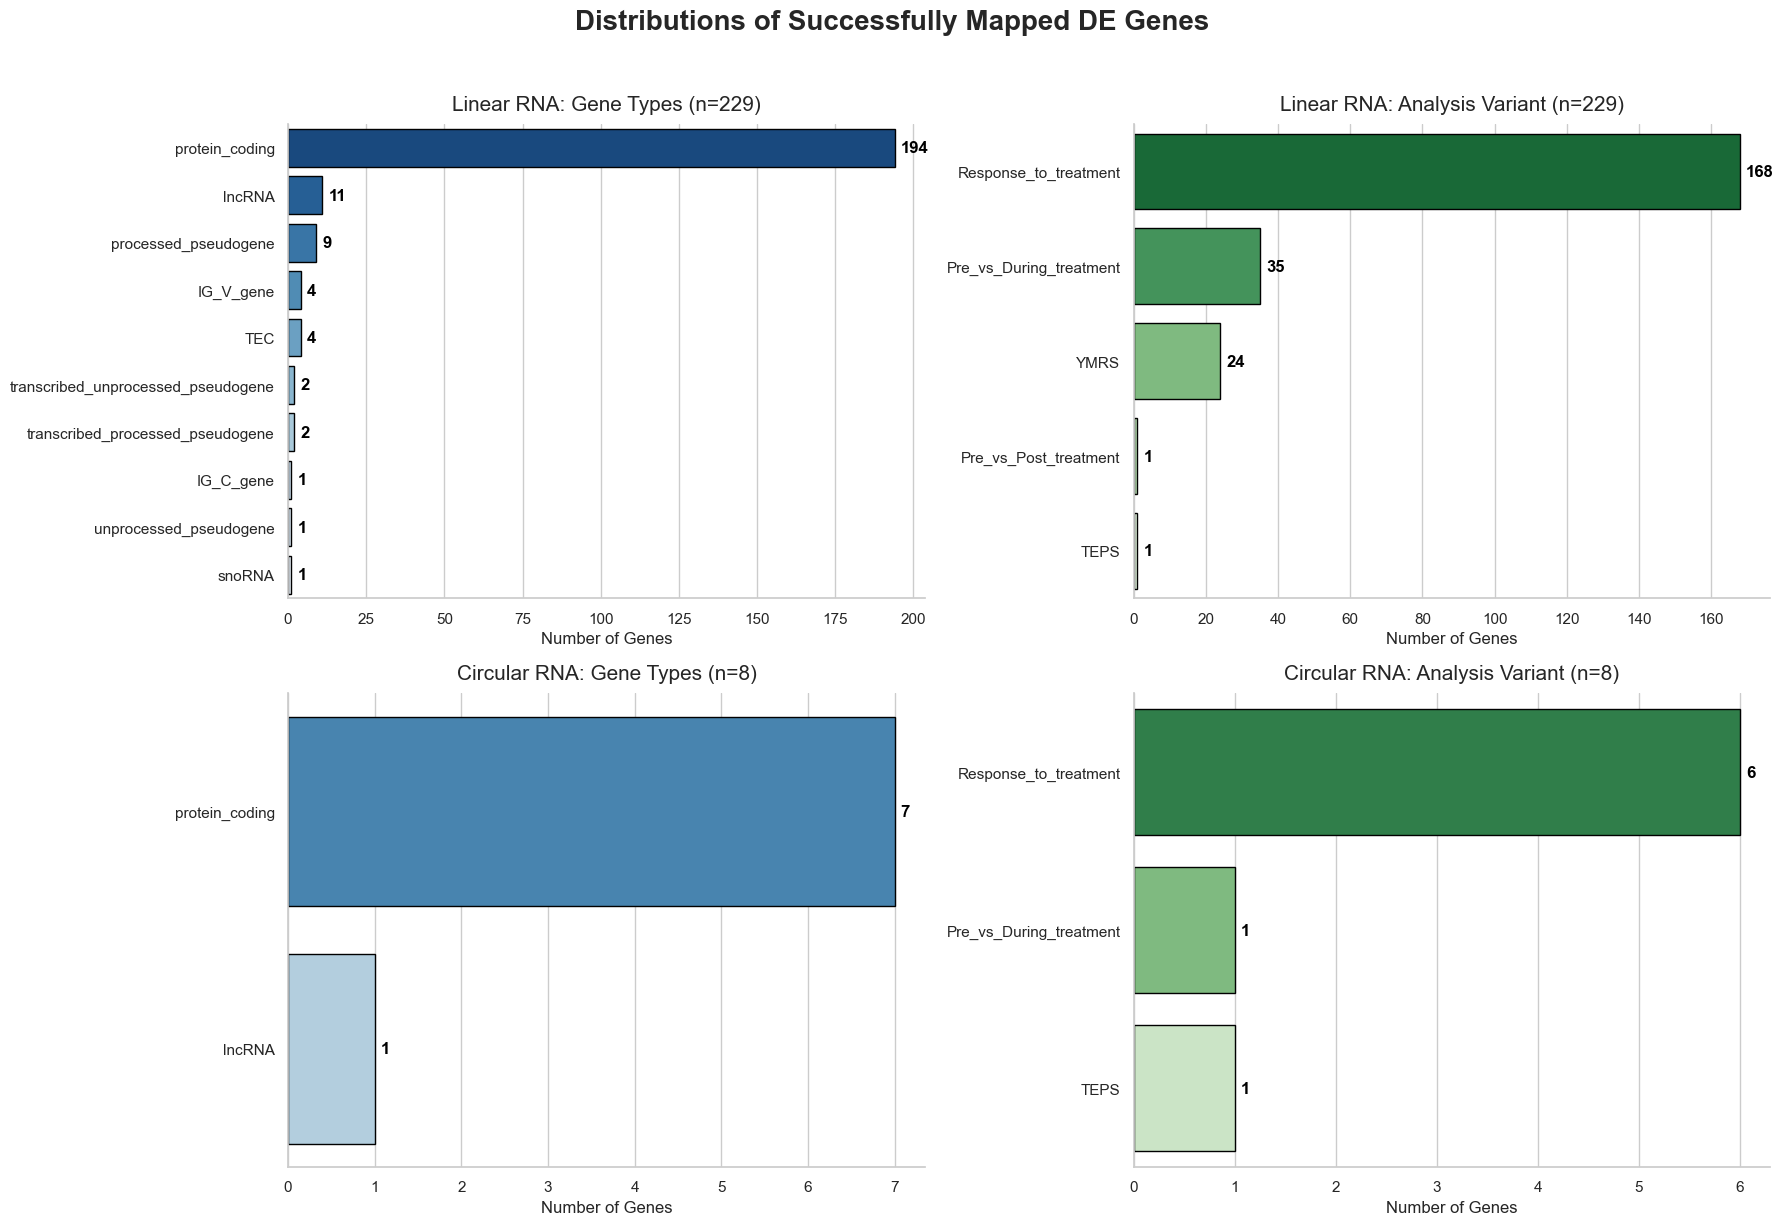

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Grab the valid subsets
mapped_lin = master_df[master_df['linRNA_ID'].notna()]
mapped_circ = master_df[master_df['circRNA_ID'].notna()]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Distributions of Successfully Mapped DE Genes', fontsize=20, fontweight='bold', y=1.02)

# Helper function to plot clean, sorted horizontal bar charts
def plot_sorted_bars(data_series, ax, title, color_palette):
    counts = data_series.value_counts().sort_values(ascending=False)
    
    # Prevent chart squashing if there are too many categories (like gene_type)
    if len(counts) > 10:
        counts = counts.head(10)
        title += " (Top 10)"
        
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette=color_palette, edgecolor='black')
    ax.set_title(title, fontsize=15, pad=10)
    ax.set_xlabel('Number of Genes', fontsize=12)
    ax.set_ylabel('')
    
    # Add exact count labels to the end of each bar
    max_val = counts.max()
    for i, v in enumerate(counts.values):
        ax.text(v + (max_val * 0.01), i, str(v), color='black', va='center', fontweight='bold')
    
    sns.despine(ax=ax)

# 1. Linear RNA: Gene Type
plot_sorted_bars(mapped_lin['gene_type'], axes[0, 0], f'Linear RNA: Gene Types (n={len(mapped_lin)})', 'Blues_r')

# 2. Linear RNA: Analysis Variant
plot_sorted_bars(mapped_lin['analysis_name'], axes[0, 1], f'Linear RNA: Analysis Variant (n={len(mapped_lin)})', 'Greens_r')

# 3. Circular RNA: Gene Type
plot_sorted_bars(mapped_circ['gene_type'], axes[1, 0], f'Circular RNA: Gene Types (n={len(mapped_circ)})', 'Blues_r')

# 4. Circular RNA: Analysis Variant
plot_sorted_bars(mapped_circ['analysis_name'], axes[1, 1], f'Circular RNA: Analysis Variant (n={len(mapped_circ)})', 'Greens_r')

plt.tight_layout()
plt.show()
